## ML regression

| feature 1 | feature 2 | feature 3 | $\ldots$ | feature k | target |
| :-: | :-: | :-: | :-: | :-: | :-: |
| $x_{11}$ | $x_{12}$ | $x_{13}$ | $\ldots$ | $x_{1k}$ | $y_1$ |
| $x_{21}$ | $x_{22}$ | $x_{23}$ | $\ldots$ | $x_{2k}$ | $y_2$ |
| $x_{31}$ | $x_{32}$ | $x_{33}$ | $\ldots$ | $x_{3k}$ | $y_3$ |
| $\ldots$ | $\ldots$ | $\ldots$ | $\ldots$ | $\ldots$ | $\ldots$ |
| $x_{n1}$ | $x_{n2}$ | $x_{n3}$ | $\ldots$ | $x_{nk}$ | $y_n$ |

- Regularized linear regression
  $$
    \arg\min_\theta \| y - X \theta \|^2 + \lambda_1 \| \theta \|_1 + \lambda_2 \| \theta \|_2
  $$
- Gradient boosting
  $$
    F_{m+1}(x_i) = F_m(x_i) + h_m(x_i) \approx y_i
  $$

## ML regression for time series forecasting

| feature 1 | feature 2 | feature 3 | $\ldots$ | feature k | target |
| :-: | :-: | :-: | :-: | :-: | :-: |
| $x_{11}$ | $x_{12}$ | $x_{13}$ | $\ldots$ | $x_{1k}$ | $y_1$ |
| $x_{21}$ | $x_{22}$ | $x_{23}$ | $\ldots$ | $x_{2k}$ | $y_2$ |
| $x_{31}$ | $x_{32}$ | $x_{33}$ | $\ldots$ | $x_{3k}$ | $y_3$ |
| $\ldots$ | $\ldots$ | $\ldots$ | $\ldots$ | $\ldots$ | $\ldots$ |
| $x_{n1}$ | $x_{n2}$ | $x_{n3}$ | $\ldots$ | $x_{nk}$ | $y_n$ |

- Take the series history $y_t, y_{t-1}, y_{t-2}, \ldots$
- Add external dynamic data $x_{t1}, x_{t2}, \ldots, x_{(t-1)1}, x_{(t-1)2}, \ldots$
- Add features like differences, combinations, rolling means, meadians, stds, etc
- Add encoded categorical features like day of week, holidays
- Add static features like classes
- Apply regression to $y_{t+1}$

## ML regression for time series forecasting

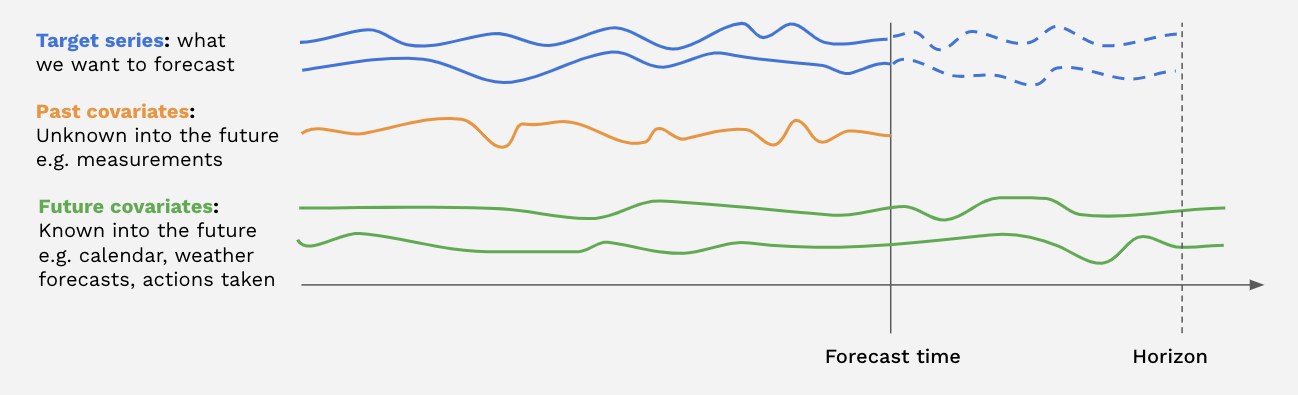

- External dynamic features was only partially available in classic time series
- External static features was not available in classic time series

In [1]:
!pip install darts astsadata

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.3/60.3 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 473.8/473.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.6/200.6 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 825.4/825.4 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 22.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd

import IPython.display as dp
import matplotlib.pyplot as plt
import seaborn as sns

dp.set_matplotlib_formats("retina")
sns.set(style="whitegrid", font_scale=1.5)
sns.despine()

%matplotlib inline

/tmp/ipython-input-3212562443.py:8: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  dp.set_matplotlib_formats("retina")


<Figure size 640x480 with 0 Axes>

In [3]:
from darts import TimeSeries
import darts.datasets as ds
import scipy.stats as sts
import statsmodels.api as sm
import statsmodels.tsa.api as tsa
from darts.utils.statistics import plot_acf

In [4]:
from darts import concatenate

In [5]:
from astsadata import cmort as cmort_pd, part as part_pd, tempr as tempr_pd

/usr/local/lib/python3.12/dist-packages/astsadata/astsadata.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  birth = pd.read_csv(f"{path}/data/birth.csv", index_col=0, parse_dates=True)
/usr/local/lib/python3.12/dist-packages/astsadata/astsadata.py:27: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cardox = pd.read_csv(f"{path}/data/cardox.csv", index_col=0, parse_dates=True)
/usr/local/lib/python3.12/dist-packages/astsadata/astsadata.py:30: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chicken = pd.read_csv(f"{path}/data/chicken.csv", index_col=0, parse_dates=True)
/usr

In [6]:
cmort = TimeSeries.from_series(
    cmort_pd["value"].rename("mort").set_axis(
        pd.date_range(
            cmort_pd.index[0].start_time.date(),
            periods=len(cmort_pd),
            freq="W-MON",
            inclusive="both"
        )
    ).resample("M").mean()
)
part = TimeSeries.from_series(
    part_pd["value"].rename("part").set_axis(
        pd.date_range(
            part_pd.index[0].start_time.date(),
            periods=len(part_pd),
            freq="W-MON",
            inclusive="both"
        )
    ).resample("M").mean()
)
tempr = TimeSeries.from_series(
    tempr_pd["value"].rename("temp").set_axis(
        pd.date_range(
            tempr_pd.index[0].start_time.date(),
            periods=len(tempr_pd),
            freq="W-MON",
            inclusive="both"
        )
    ).resample("M").mean()
)

/tmp/ipython-input-738212454.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ).resample("M").mean()
/tmp/ipython-input-738212454.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ).resample("M").mean()
/tmp/ipython-input-738212454.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ).resample("M").mean()


In [7]:
cmort_train, cmort_test = cmort.split_before(pd.Timestamp("1978-01-01"))
part_cov, _ = part.split_before(pd.Timestamp("1978-01-01"))
temp_cov = tempr

<Axes: xlabel='time'>

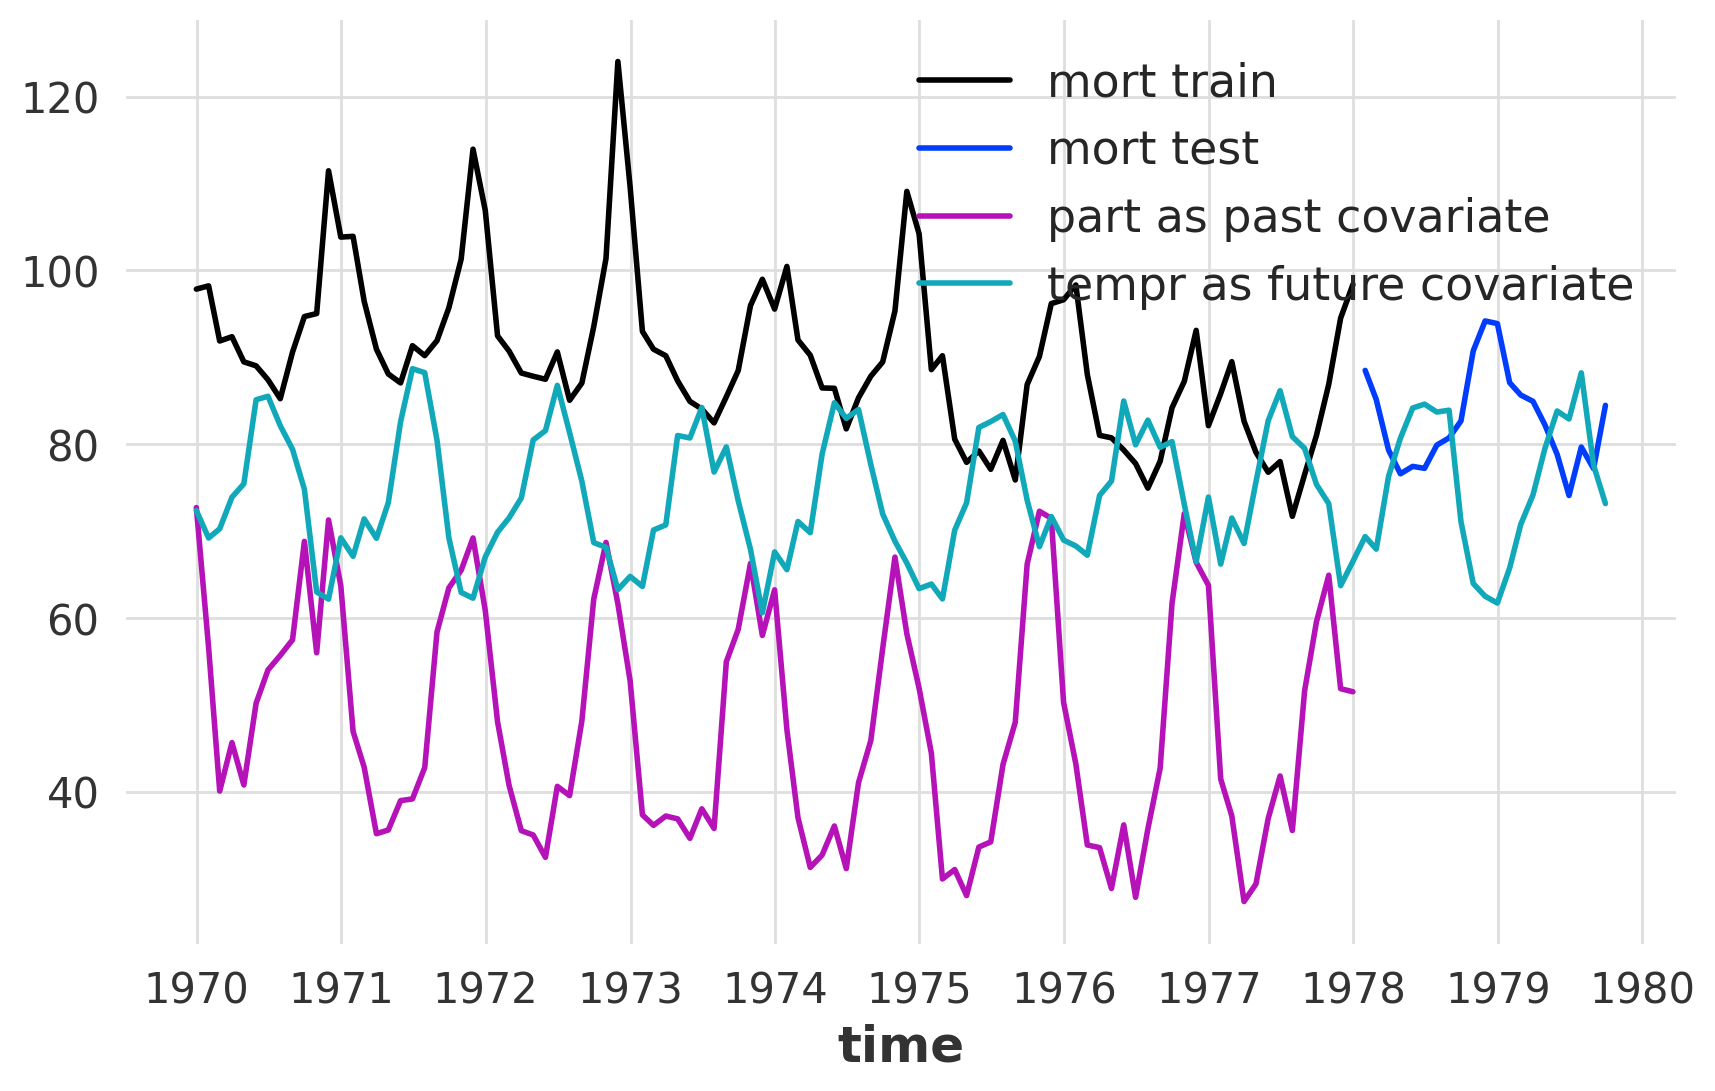

In [8]:
fig, ax = plt.subplots(figsize=(10,6))
cmort_train.plot(ax=ax, label="mort train")
cmort_test.plot(ax=ax, label="mort test")
part_cov.plot(ax=ax, label="part as past covariate")
temp_cov.plot(ax=ax, label="tempr as future covariate")

In [9]:
from darts.models import LinearRegressionModel, RegressionModel, RandomForest, XGBModel, CatBoostModel

In [10]:
from darts.metrics import mape

In [11]:
model = LinearRegressionModel(
    lags=[-1, -2, -3, -4, -5, -6],
    output_chunk_length=20,
)
model.fit(cmort_train);
pred = model.predict(20)

In [12]:
model_past = LinearRegressionModel(
    lags=[-1, -2, -3, -4, -5, -6],
    lags_past_covariates=[-1, -2, -3, -4, -5, -6],
    output_chunk_length=20,
)
model_past.fit(cmort_train, past_covariates=part_cov);
pred_past = model_past.predict(20)

In [13]:
model_future = LinearRegressionModel(
    lags=[-1, -2, -3, -4, -5, -6],
    lags_future_covariates=[0, -1, -2, -3, -4, -5, -6],
    output_chunk_length=20,
)
model_future.fit(cmort_train, future_covariates=temp_cov);
pred_future = model_future.predict(20)

In [14]:
model_past_future = LinearRegressionModel(
    lags=[-1, -2, -3, -4, -5, -6],
    lags_past_covariates=[-1, -2, -3, -4, -5, -6],
    lags_future_covariates=[0, -1, -2, -3, -4, -5, -6],
    output_chunk_length=20,
)
model_past_future.fit(cmort_train, past_covariates=part_cov, future_covariates=temp_cov);
pred_past_future = model_past_future.predict(20)

<Axes: xlabel='time'>

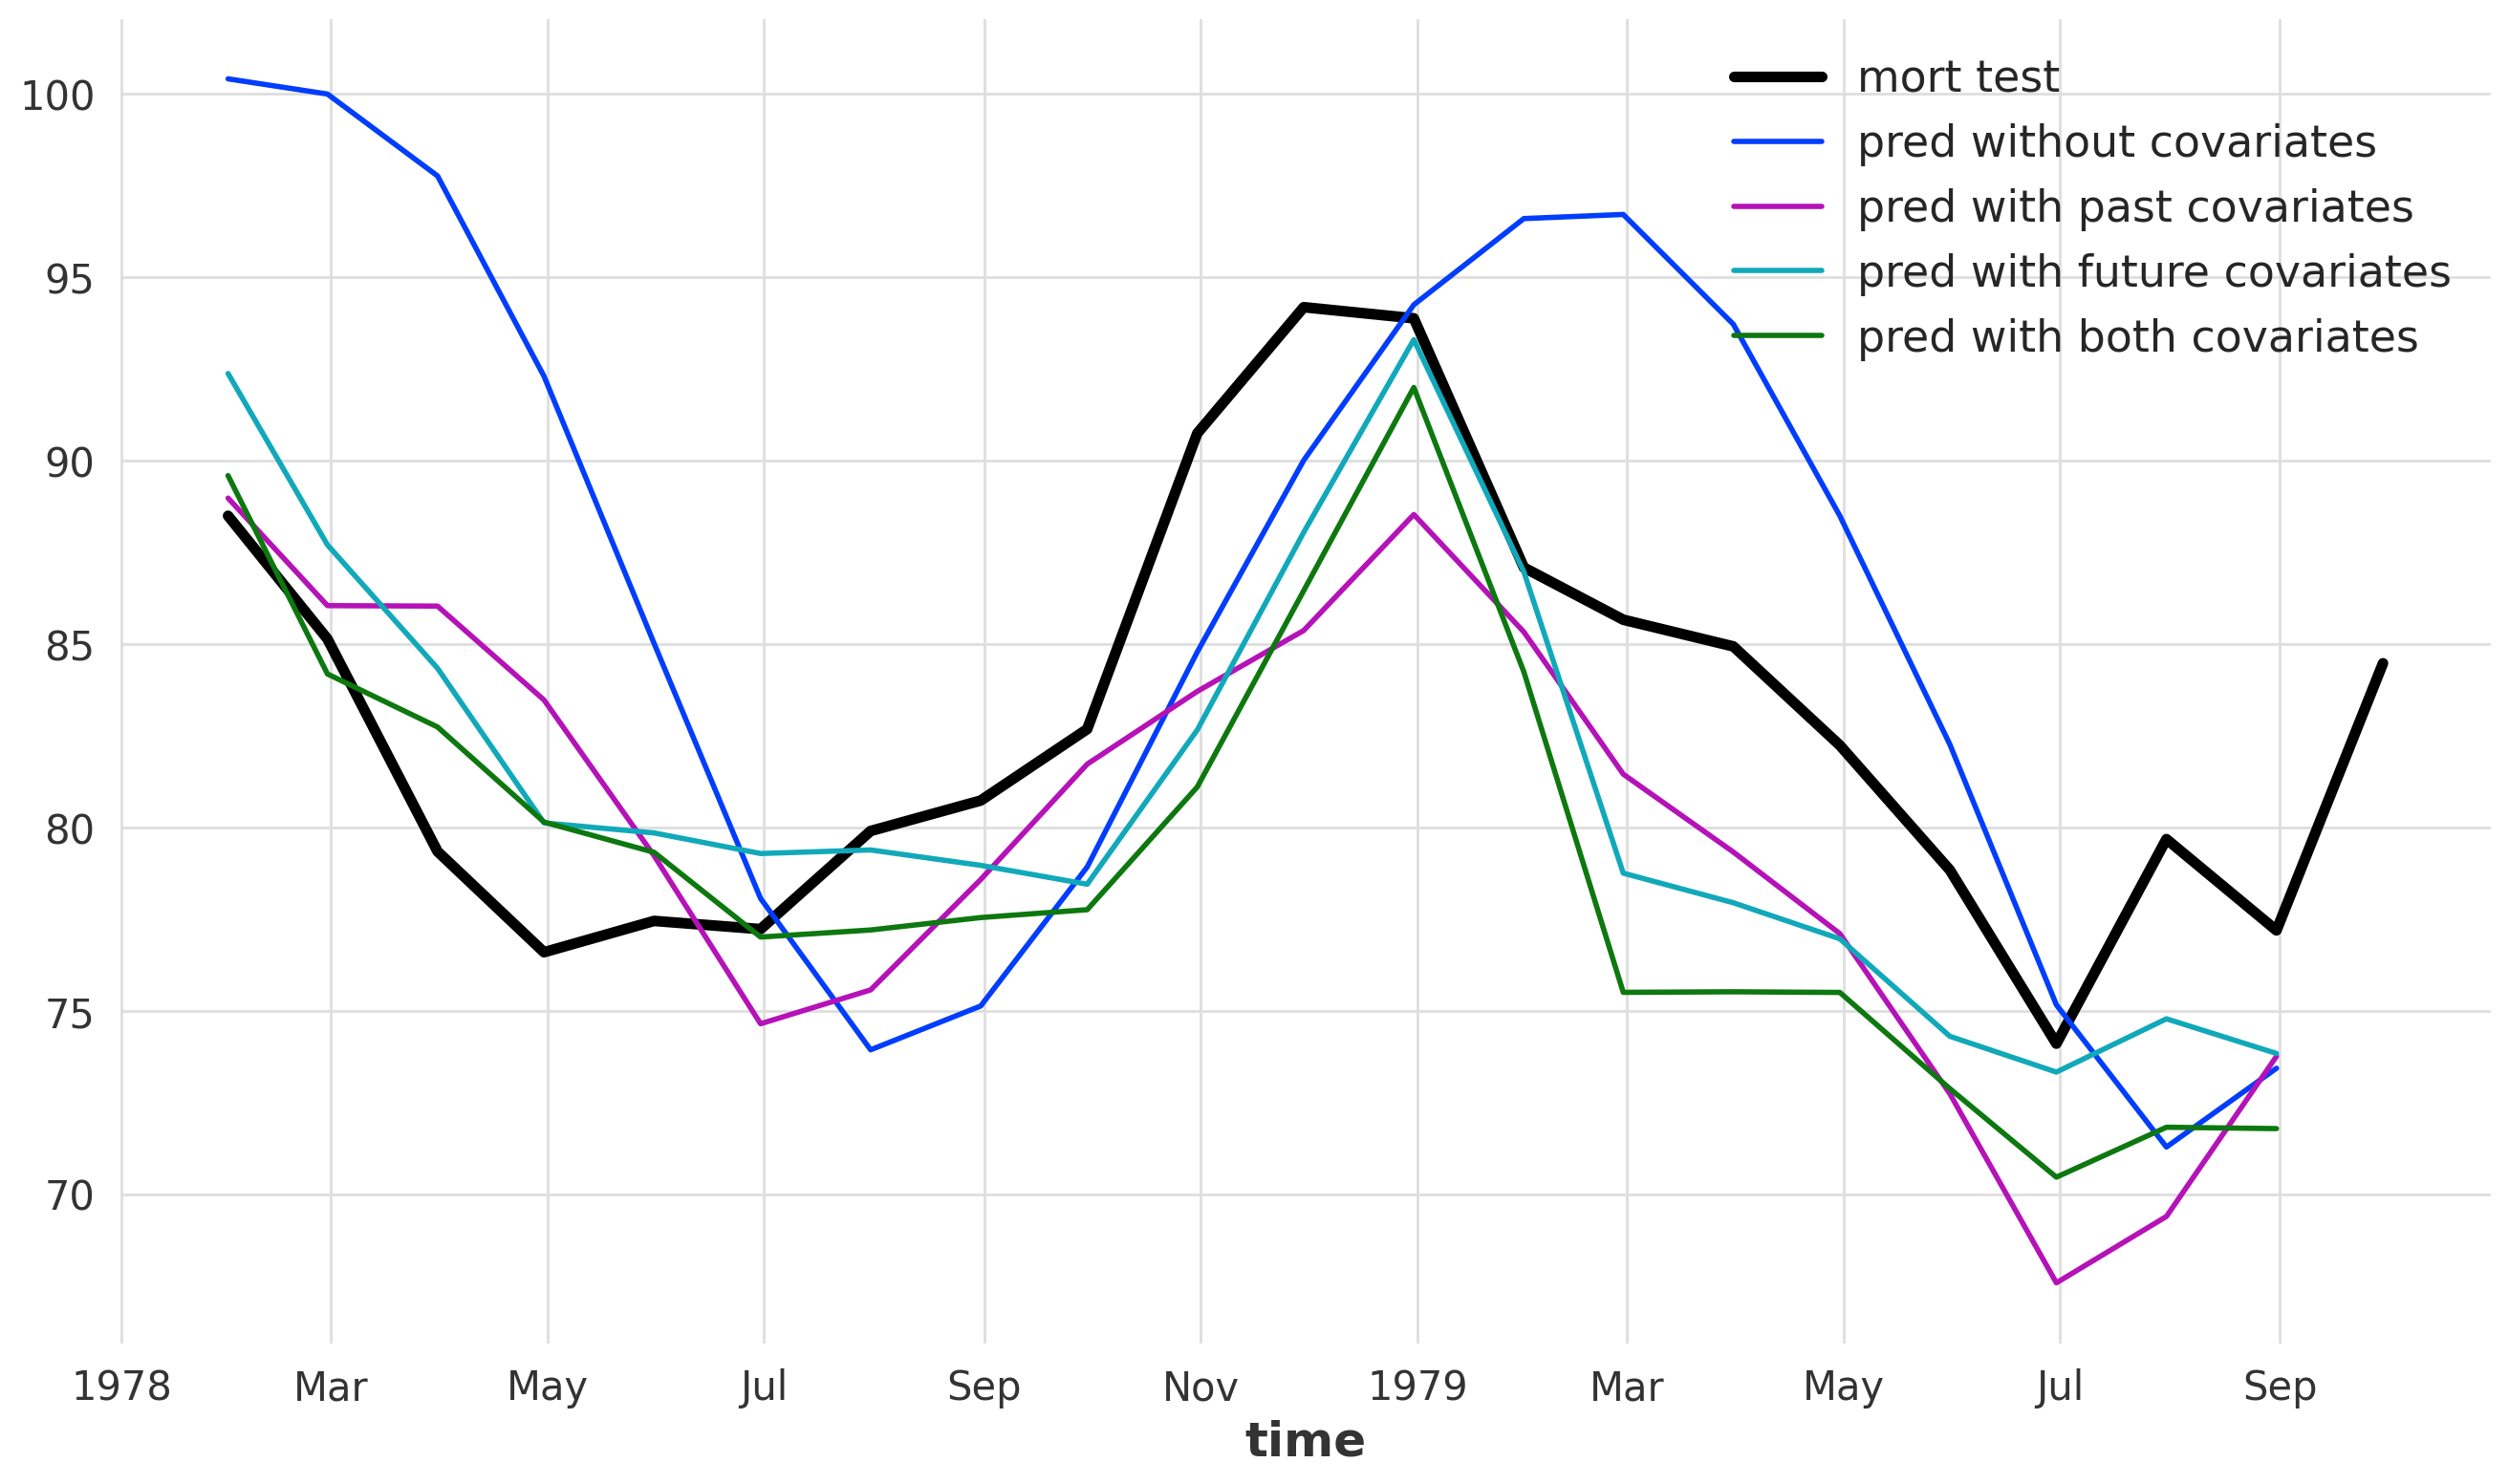

In [15]:
fig, ax = plt.subplots(figsize=(16,9))
cmort_test.plot(ax=ax, lw=4, label="mort test")
pred.plot(ax=ax, label="pred without covariates")
pred_past.plot(ax=ax, label="pred with past covariates")
pred_future.plot(ax=ax, label="pred with future covariates")
pred_past_future.plot(ax=ax, label="pred with both covariates")

In [16]:
mape(
    [cmort_test, cmort_test, cmort_test, cmort_test],
    [pred, pred_past, pred_future, pred_past_future]
)

[np.float64(8.93734150711126),
 np.float64(5.518518759087553),
 np.float64(4.408916516691453),
 np.float64(5.590476275937457)]

## Cross-validation

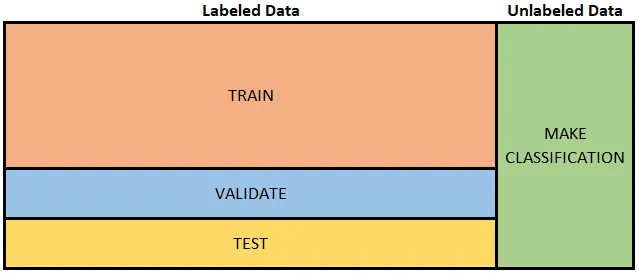

- Pro: trains using latest data
- Con: no idea how model performs out-of-time

## Cross-validation of time series (out-of-time)

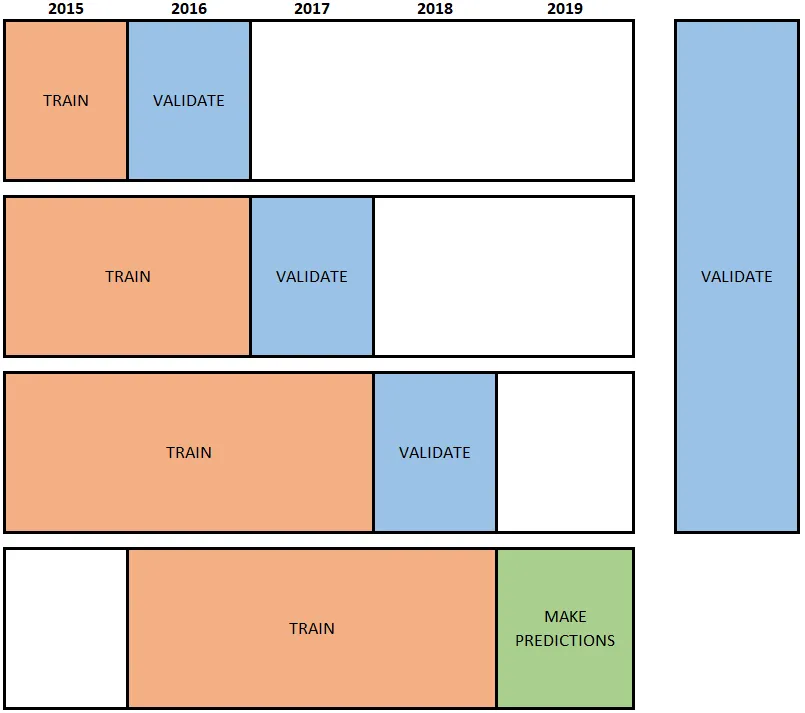

- Pro: model building takes into account ability to predict out-of-time
- Con: validation set is not random

In [17]:
model = LinearRegressionModel(
    lags=[-1, -2, -3, -4, -5, -6],
    lags_future_covariates=[0, -1, -2, -3, -4, -5, -6],
)
historical_forecasts = model.historical_forecasts(
    cmort_train, future_covariates=temp_cov, train_length=36, forecast_horizon=12, stride=12, last_points_only=False,
);

In [18]:
[f"{forecast.start_time()} - {forecast.end_time()}, {len(forecast)} values" for forecast in historical_forecasts]

['1972-12-31 00:00:00 - 1973-11-30 00:00:00, 12 values',
 '1973-12-31 00:00:00 - 1974-11-30 00:00:00, 12 values',
 '1974-12-31 00:00:00 - 1975-11-30 00:00:00, 12 values',
 '1975-12-31 00:00:00 - 1976-11-30 00:00:00, 12 values',
 '1976-12-31 00:00:00 - 1977-11-30 00:00:00, 12 values']

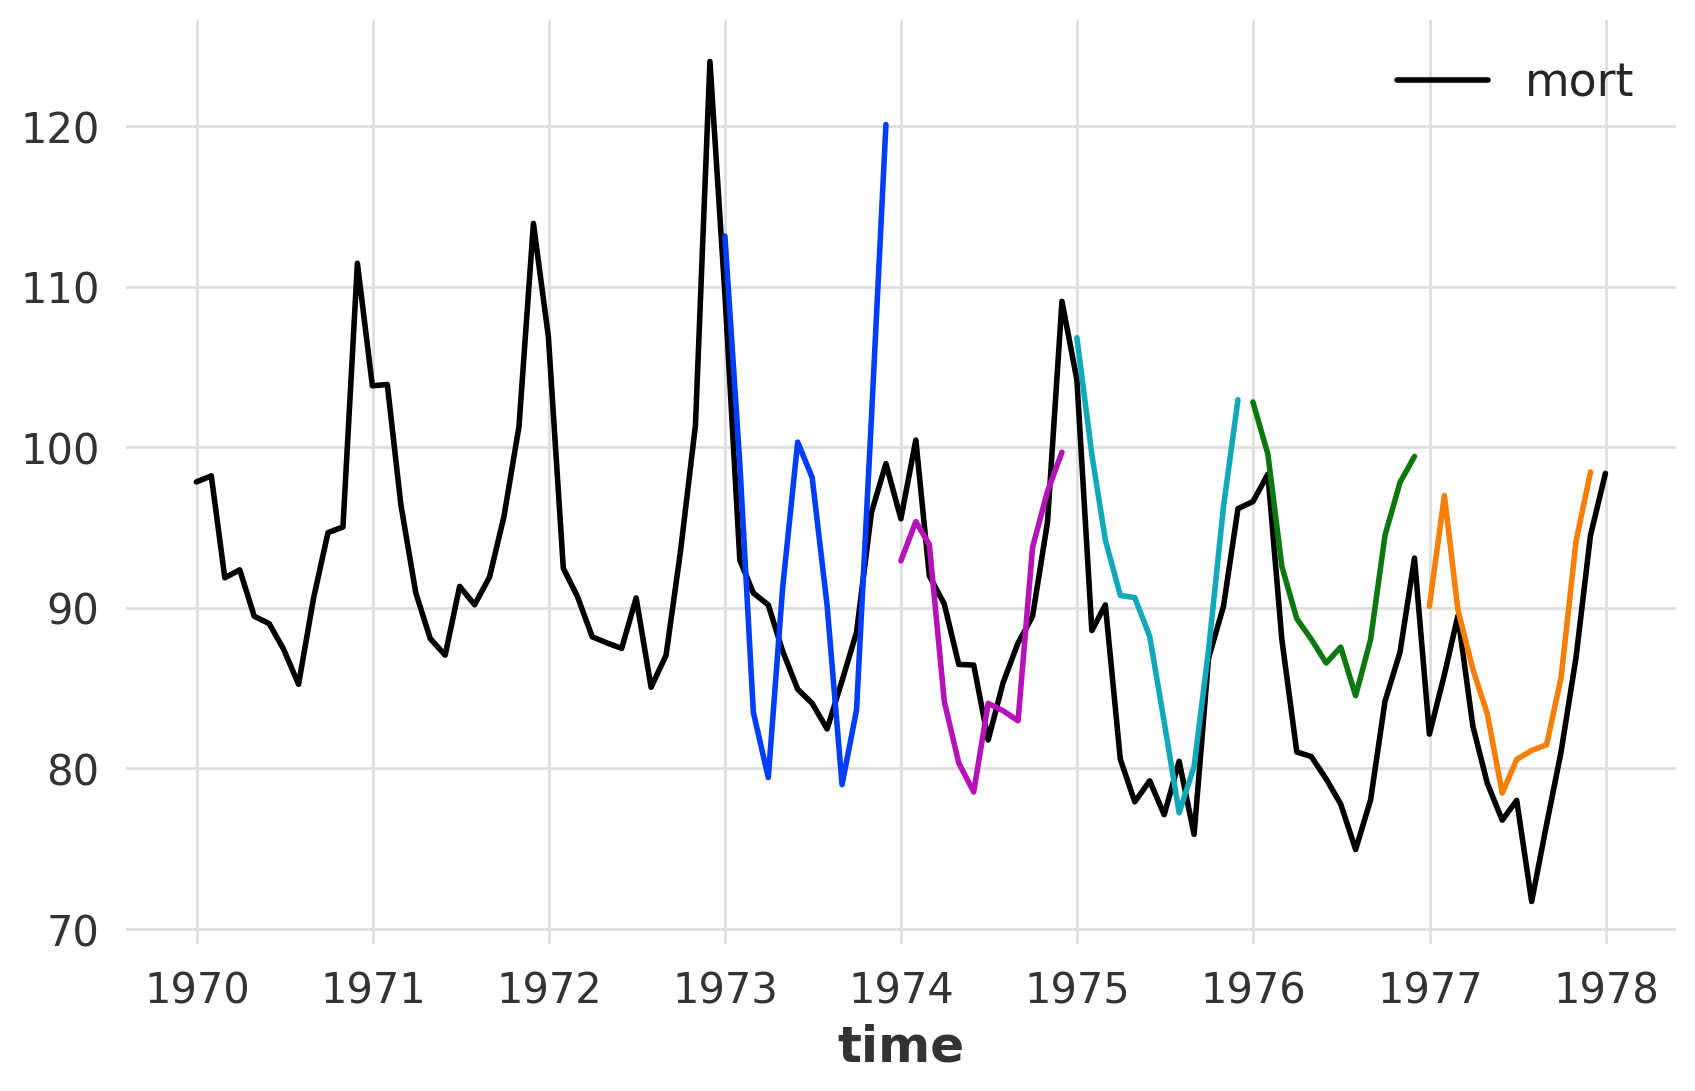

In [20]:
fig, ax = plt.subplots(figsize=(10,6))
cmort_train.plot(ax=ax)
[forecast.plot(label=None, ax=ax) for forecast in historical_forecasts];

In [21]:
model = LinearRegressionModel(
    lags=[-1, -2, -3, -4, -5, -6],
    lags_future_covariates=[0, -1, -2, -3, -4, -5, -6],
)
historical_forecasts = model.historical_forecasts(
    cmort_train, future_covariates=temp_cov, train_length=36, forecast_horizon=12, stride=6, last_points_only=False,
);

In [22]:
[f"{forecast.start_time()} - {forecast.end_time()}, {len(forecast)} values" for forecast in historical_forecasts]

['1972-12-31 00:00:00 - 1973-11-30 00:00:00, 12 values',
 '1973-06-30 00:00:00 - 1974-05-31 00:00:00, 12 values',
 '1973-12-31 00:00:00 - 1974-11-30 00:00:00, 12 values',
 '1974-06-30 00:00:00 - 1975-05-31 00:00:00, 12 values',
 '1974-12-31 00:00:00 - 1975-11-30 00:00:00, 12 values',
 '1975-06-30 00:00:00 - 1976-05-31 00:00:00, 12 values',
 '1975-12-31 00:00:00 - 1976-11-30 00:00:00, 12 values',
 '1976-06-30 00:00:00 - 1977-05-31 00:00:00, 12 values',
 '1976-12-31 00:00:00 - 1977-11-30 00:00:00, 12 values']

ERROR:darts.timeseries:IndexError: Integer index out of range.


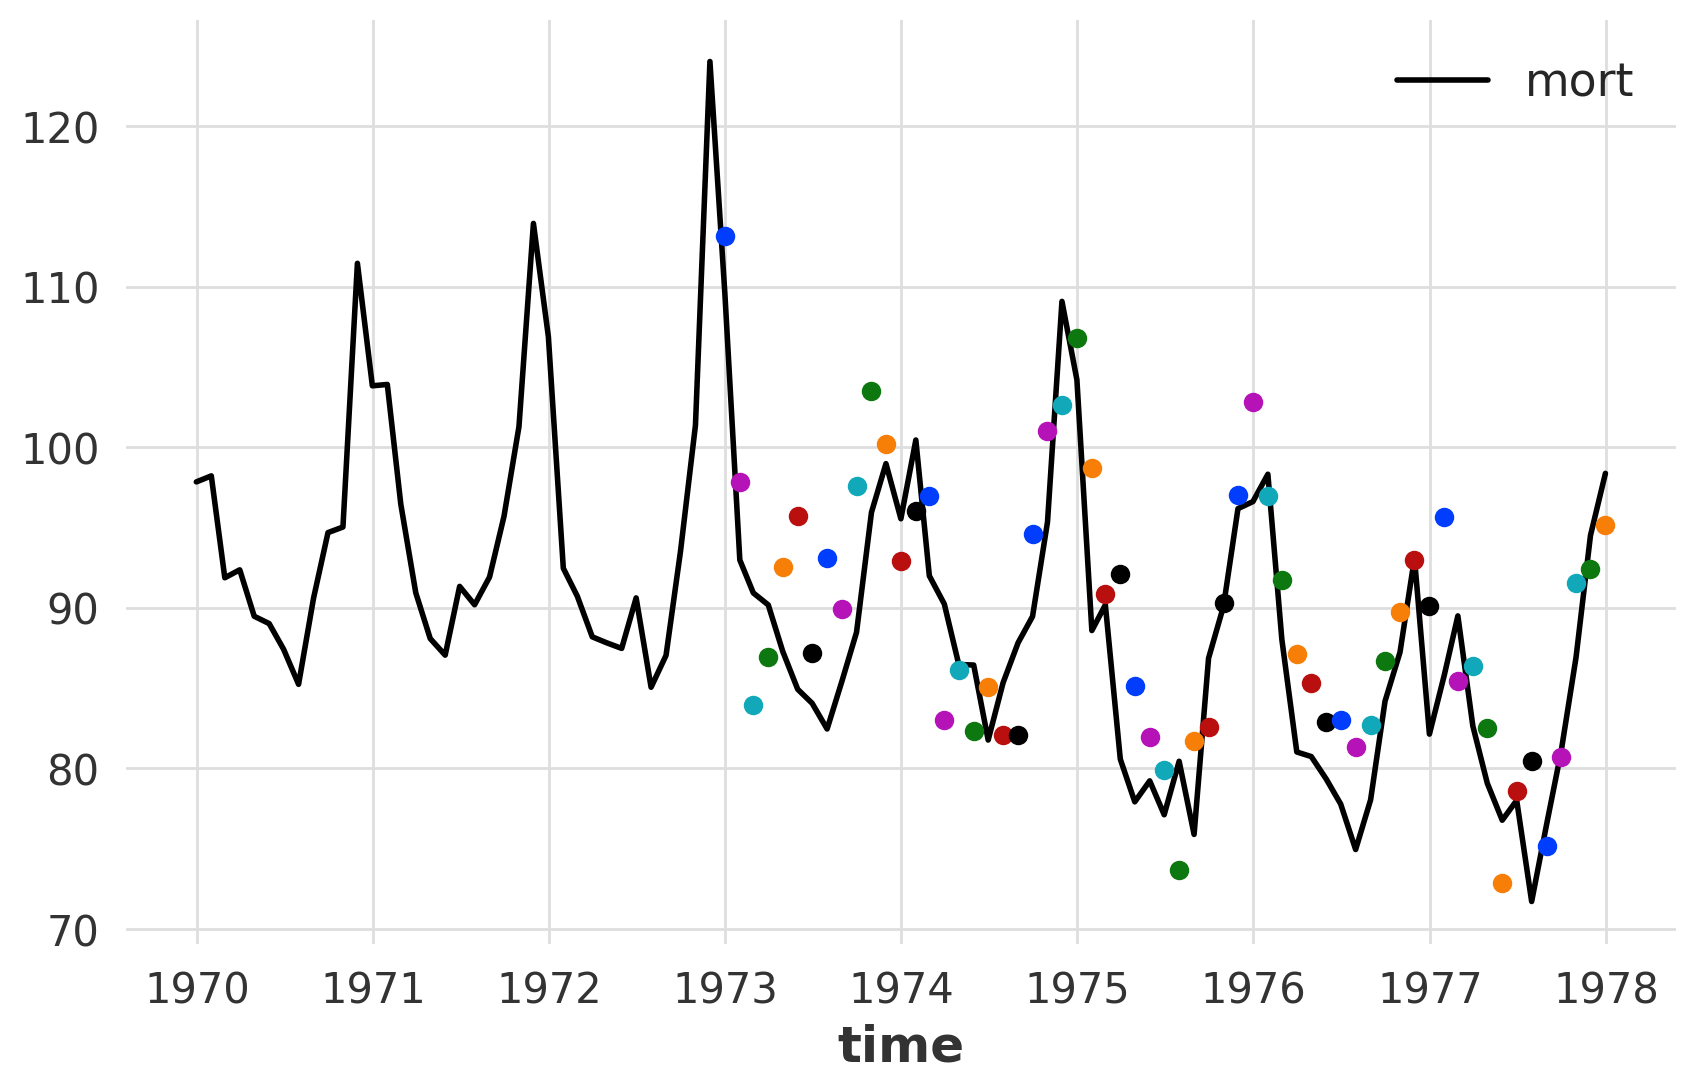

In [25]:
fig, ax = plt.subplots(figsize=(10,6))
cmort_train.plot(ax=ax)
[forecast.plot(label=None, ax=ax) for forecast in historical_forecasts];

In [26]:
model = LinearRegressionModel(
    lags=[-1, -2, -3, -4, -5, -6],
    lags_future_covariates=[0, -1, -2, -3, -4, -5, -6],
)
historical_forecasts = model.historical_forecasts(
    cmort_train, future_covariates=temp_cov, train_length=36, forecast_horizon=1, stride=1, last_points_only=True,
);

<Axes: xlabel='time'>

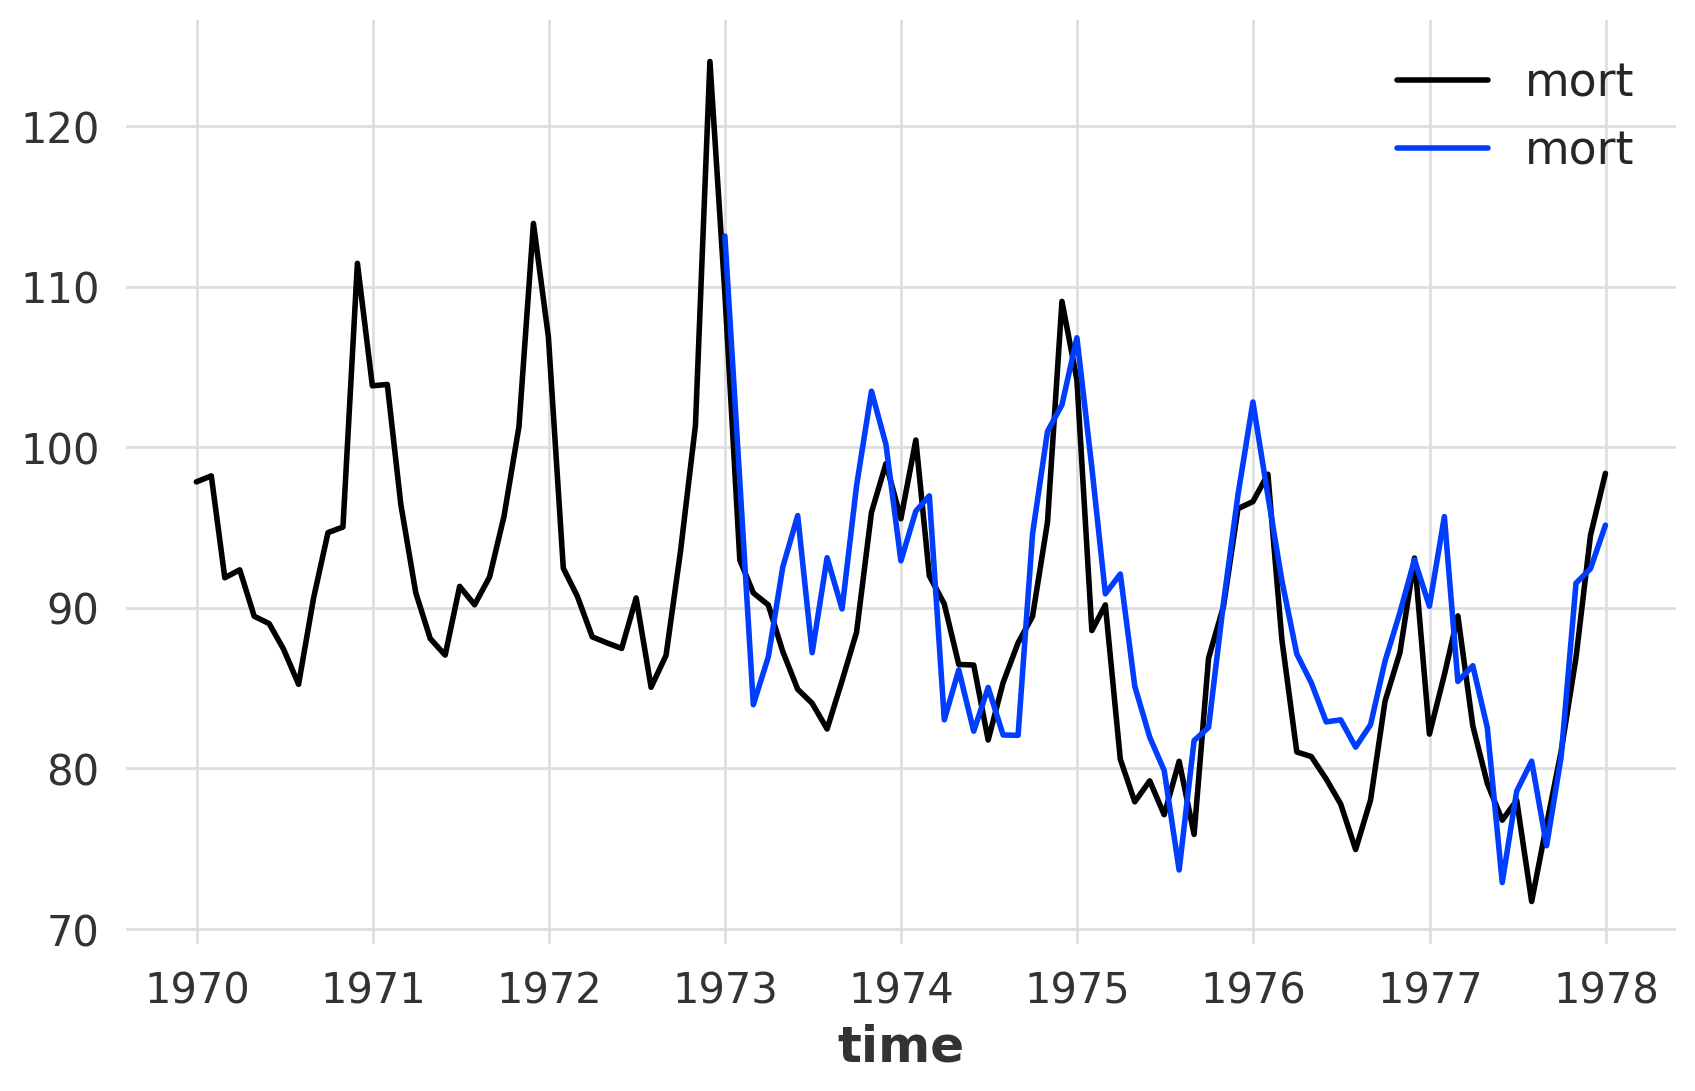

In [28]:
fig, ax = plt.subplots(figsize=(10,6))
cmort_train.plot(ax=ax)
historical_forecasts.plot(ax=ax)

## Features for time series

Where to take covariates from? It would be nice to have a storage of all time series in the world and always use everything for predictions... but
- Too much features
- [Spurious correlations](https://www.tylervigen.com/spurious-correlations)
- Hard to collect

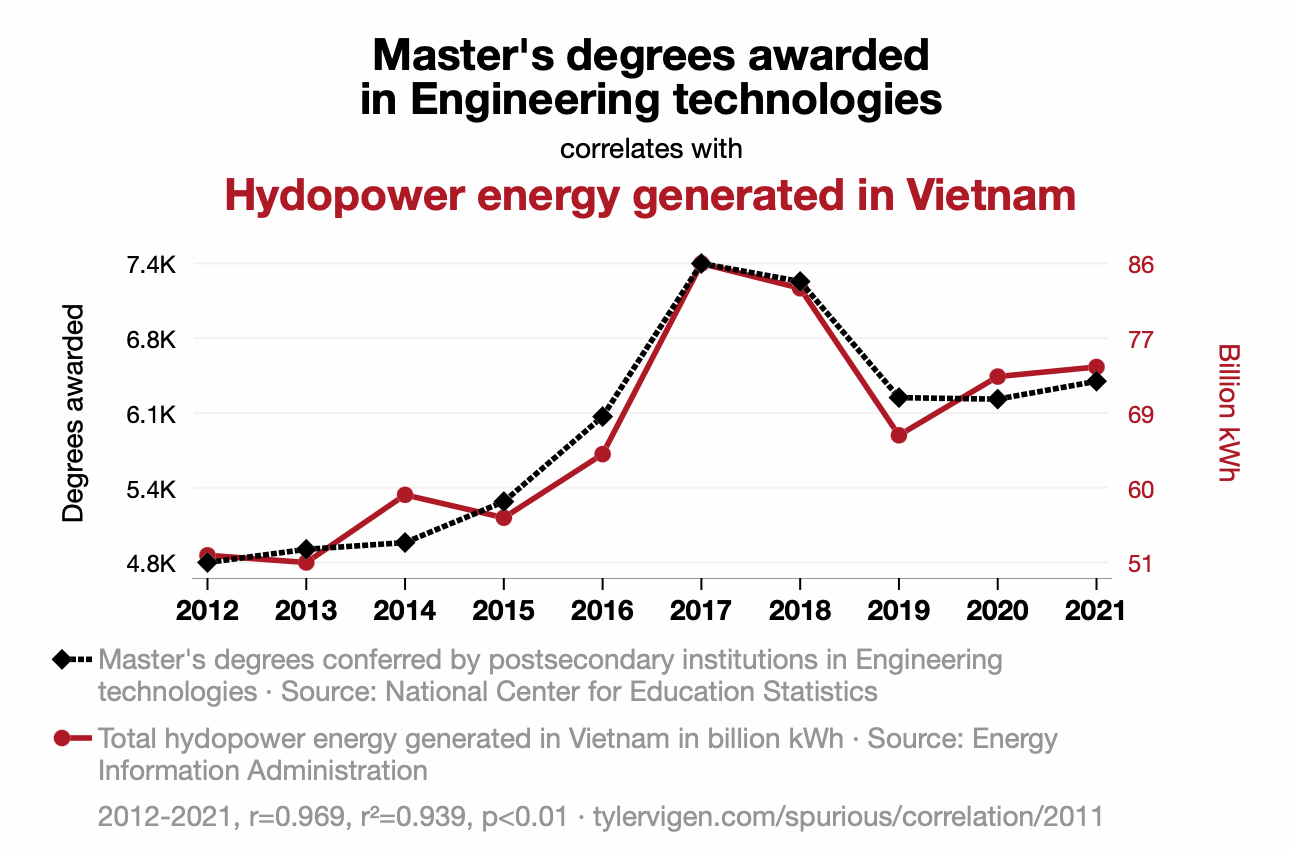

## Features for time series

Where to take covariates from? **tsfresh** is a package that does automatic extraction of up to 1558 features, provides a feature selection procedure.

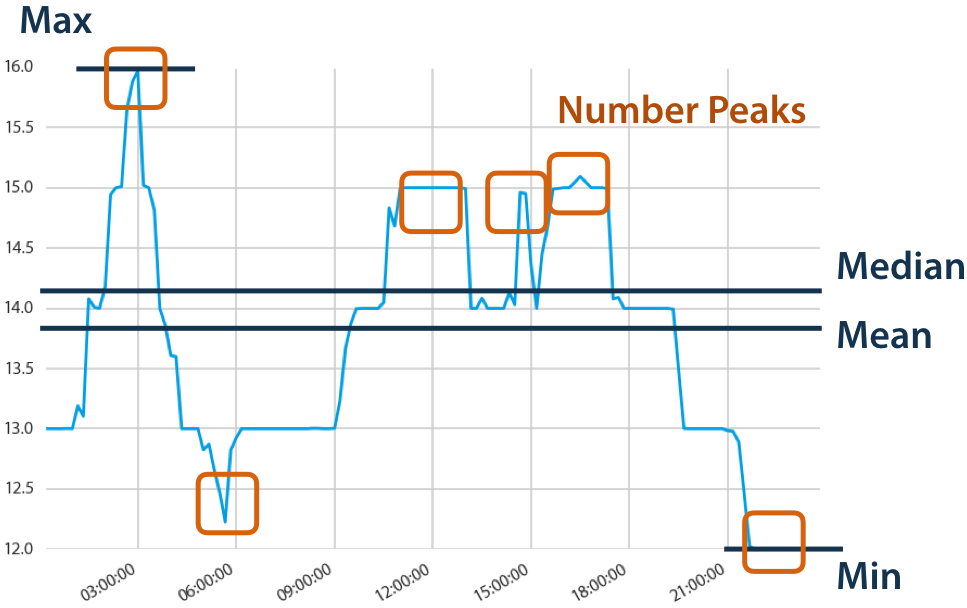

In [29]:
!pip install tsfresh

In [30]:
from tsfresh.feature_extraction import extract_features
from tsfresh.feature_selection import select_features

In [34]:
import pickle

In [35]:
with open("returns_NASDAQ_hist_daily_06102021-091329.pkl", "rb") as f:
    data = pickle.load(f)

/tmp/ipython-input-2687517587.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


In [36]:
data.head()

,Ticker,Close
Time,,
1999-11-01,ATVI,NaN
1999-11-02,ATVI,1.351351
1999-11-03,ATVI,1.754386
1999-11-04,ATVI,0.827586
1999-11-05,ATVI,5.198358


In [37]:
data["Ticker"].unique()

array(['ATVI', 'ADBE', 'AMD', 'ALXN', 'ALGN', 'GOOG', 'AMZN', 'AAL',
       'AMGN', 'ADI', 'AAPL', 'AMAT', 'ASML', 'ADSK', 'ADP', 'BIDU',
       'BIIB', 'BMRN', 'BKNG', 'AVGO', 'CDNS', 'CELG', 'CERN', 'CHTR',
       'CHKP', 'CTAS', 'CSCO', 'CTXS', 'CTSH', 'CMCSA', 'COST', 'CSX',
       'CTRP', 'DLTR', 'EBAY', 'EA', 'EXPE', 'FB', 'FAST', 'FISV', 'FOX',
       'GILD', 'HAS', 'HSIC', 'IDXX', 'ILMN', 'INCY', 'INTC', 'INTU',
       'ISRG', 'JBHT', 'JD', 'KLAC', 'LRCX', 'LBTYA', 'LULU', 'MAR',
       'MXIM', 'MELI', 'MCHP', 'MU', 'MSFT', 'MDLZ', 'MNST', 'NTAP',
       'NTES', 'NFLX', 'NVDA', 'NXPI', 'ORLY', 'PCAR', 'PAYX', 'PYPL',
       'PEP', 'QCOM', 'REGN', 'ROST', 'SIRI', 'SWKS', 'SBUX', 'SYMC',
       'SNPS', 'TTWO', 'TSLA', 'TXN', 'KHC', 'TMUS', 'ULTA', 'UAL',
       'VRSN', 'VRSK', 'VRTX', 'WBA', 'WDC', 'WLTW', 'WDAY', 'WYNN',
       'XEL', 'XLNX'], dtype=object)

In [38]:
data_tsla = data[data["Ticker"] == "TSLA"]

In [39]:
data_tsla = data_tsla.sort_index().reset_index()

In [40]:
data_tsla.head()

,Time,Ticker,Close
0,2010-06-29,TSLA,NaN
1,2010-06-30,TSLA,-0.251151
2,2010-07-01,TSLA,-7.847251
3,2010-07-02,TSLA,-12.568306
4,2010-07-06,TSLA,-16.093750


In [41]:
data_tsla.tail()

,Time,Ticker,Close
2833,2021-09-29,TSLA,0.482278
2834,2021-09-30,TSLA,-0.746183
2835,2021-10-01,TSLA,-0.033528
2836,2021-10-04,TSLA,0.813962
2837,2021-10-05,TSLA,-0.120277


<Axes: xlabel='Time'>

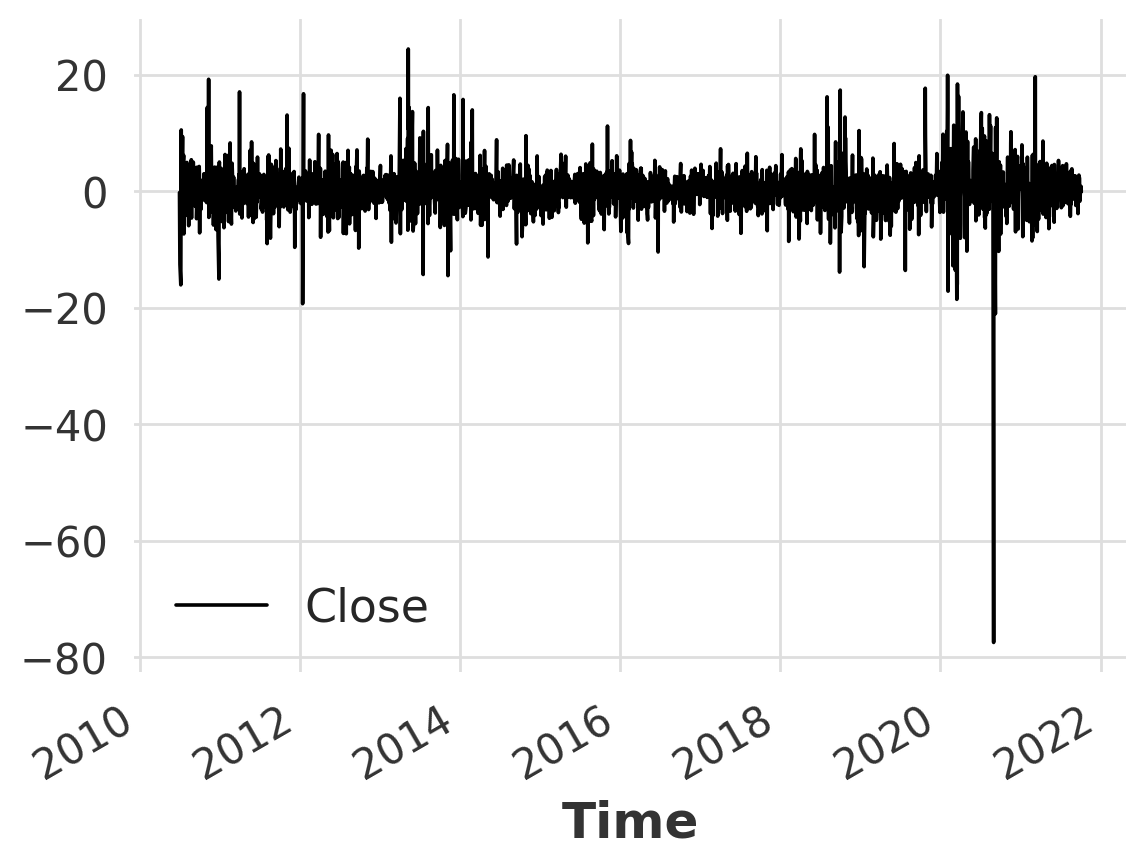

In [42]:
data_tsla.plot(x="Time", y="Close")

In [43]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import roll_time_series, make_forecasting_frame
from tsfresh.utilities.dataframe_functions import impute

In [44]:
data_rolled = roll_time_series(
    data_tsla,
    column_id="Ticker",
    column_sort="Time",
    max_timeshift=20,
    min_timeshift=5,
)

/usr/local/lib/python3.12/dist-packages/tsfresh/utilities/dataframe_functions.py:520: UserWarning: Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.
  warnings.warn(
Rolling: 100%|██████████| 2838/2838 [00:04<00:00, 606.83it/s]


In [45]:
data_rolled.head()

,Time,Ticker,Close,id
0,2010-06-29,TSLA,NaN,"(TSLA, 2010-07-07 00:00:00)"
1,2010-06-30,TSLA,-0.251151,"(TSLA, 2010-07-07 00:00:00)"
2,2010-07-01,TSLA,-7.847251,"(TSLA, 2010-07-07 00:00:00)"
3,2010-07-02,TSLA,-12.568306,"(TSLA, 2010-07-07 00:00:00)"
4,2010-07-06,TSLA,-16.093750,"(TSLA, 2010-07-07 00:00:00)"


In [46]:
data_rolled[(data_rolled["Time"] == pd.Timestamp("20100707"))]

,Time,Ticker,Close,id
5,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-07 00:00:00)"
11,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-08 00:00:00)"
18,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-09 00:00:00)"
26,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-12 00:00:00)"
35,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-13 00:00:00)"
45,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-14 00:00:00)"
56,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-15 00:00:00)"
68,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-16 00:00:00)"
81,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-19 00:00:00)"
95,2010-07-07,TSLA,-1.924271,"(TSLA, 2010-07-20 00:00:00)"


In [47]:
X = extract_features(
    data_rolled.drop("Ticker", axis=1).fillna(0),
    column_id="id",
    column_sort="Time",
    column_value="Close",
    impute_function=impute,
    show_warnings=False
)

Feature Extraction: 100%|██████████| 2833/2833 [05:42<00:00,  8.27it/s]


In [48]:
X.head()

Close__variance_larger_than_standard_deviation  \
TSLA 2010-07-07                                             1.0   
     2010-07-08                                             1.0   
     2010-07-09                                             1.0   
     2010-07-12                                             1.0   
     2010-07-13                                             1.0   

                 Close__has_duplicate_max  Close__has_duplicate_min  \
TSLA 2010-07-07                       0.0                       0.0   
     2010-07-08                       0.0                       0.0   
     2010-07-09                       0.0                       0.0   
     2010-07-12                       0.0                       0.0   
     2010-07-13                       0.0                       0.0   

                 Close__has_duplicate  Close__sum_values  Close__abs_energy  \
TSLA 2010-07-07                   0.0         -38.684729         482.316353   
     2010-07-08                   0.0         -28.178400         592.699305   
     2010-07-09                   0.0         -28.522043         592.817395   
     2010-07-12                   0.0         -30.533537         596.863504   
     2010-07-13                   0.0         -24.140575         637.733466   

                 Close__mean_abs_change  Close__mean_change  \
TSLA 2010-07-07                6.052646           -0.384854   
     2010-07-08                7.115638            1.751055   
     2010-07-09                7.649114           -0.049092   
     2010-07-12                6.901457           -0.251437   
     2010-07-13                7.068457            0.710329   

                 Close__mean_second_derivative_central  Close__median  ...  \
TSLA 2010-07-07                               1.802579      -4.885761  ...   
     2010-07-08                               1.268175      -1.924271  ...   
     2010-07-09                              -0.883235      -1.133957  ...   
     2010-07-12                              -0.101193      -1.924271  ...   
     2010-07-13                               0.540975      -1.133957  ...   

                 Close__fourier_entropy__bins_5  \
TSLA 2010-07-07                        1.039721   
     2010-07-08                        1.039721   
     2010-07-09                        0.950271   
     2010-07-12                        1.054920   
     2010-07-13                        1.011404   

                 Close__fourier_entropy__bins_10  \
TSLA 2010-07-07                         1.386294   
     2010-07-08                         1.039721   
     2010-07-09                         1.332179   
     2010-07-12                         1.054920   
     2010-07-13                         1.242453   

                 Close__fourier_entropy__bins_100  \
TSLA 2010-07-07                          1.386294   
     2010-07-08                          1.386294   
     2010-07-09                          1.609438   
     2010-07-12                          1.332179   
     2010-07-13                          1.791759   

                 Close__permutation_entropy__dimension_3__tau_1  \
TSLA 2010-07-07                                        0.562335   
     2010-07-08                                        0.950271   
     2010-07-09                                        1.242453   
     2010-07-12                                        1.153742   
     2010-07-13                                        1.213008   

                 Close__permutation_entropy__dimension_4__tau_1  \
TSLA 2010-07-07                                        0.636514   
     2010-07-08                                        1.039721   
     2010-07-09                                        1.332179   
     2010-07-12                                        1.560710   
     2010-07-13                                        1.747868   

                 Close__permutation_entropy__dimension_5__tau_1  \
TSLA 2010-07-07                                     

In [49]:
X.shape

(2833, 783)

In [50]:
X = X.set_index(X.index.map(lambda x: x[1]), drop=True)
X.index.name = "last_date"
X.head()

,Close__variance_larger_than_standard_deviation,Close__has_duplicate_max,Close__has_duplicate_min,Close__has_duplicate,Close__sum_values,Close__abs_energy,Close__mean_abs_change,Close__mean_change,Close__mean_second_derivative_central,Close__median,...,Close__fourier_entropy__bins_5,Close__fourier_entropy__bins_10,Close__fourier_entropy__bins_100,Close__permutation_entropy__dimension_3__tau_1,Close__permutation_entropy__dimension_4__tau_1,Close__permutation_entropy__dimension_5__tau_1,Close__permutation_entropy__dimension_6__tau_1,Close__permutation_entropy__dimension_7__tau_1,Close__query_similarity_count__query_None__threshold_0.0,Close__mean_n_absolute_max__number_of_maxima_7
last_date,,,,,,,,,,,,,,,,,,,,,
2010-07-07,1.0,0.0,0.0,0.0,-38.684729,482.316353,6.052646,-0.384854,1.802579,-4.885761,...,1.039721,1.386294,1.386294,0.562335,0.636514,0.693147,-0.000000,2.708050,0.0,4.215944
2010-07-08,1.0,0.0,0.0,0.0,-28.178400,592.699305,7.115638,1.751055,1.268175,-1.924271,...,1.039721,1.039721,1.386294,0.950271,1.039721,1.098612,0.693147,-0.000000,0.0,4.215944
2010-07-09,1.0,0.0,0.0,0.0,-28.522043,592.817395,7.649114,-0.049092,-0.883235,-1.133957,...,0.950271,1.332179,1.609438,1.242453,1.332179,1.386294,1.098612,0.693147,0.0,7.076386
2010-07-12,1.0,0.0,0.0,0.0,-30.533537,596.863504,6.901457,-0.251437,-0.101193,-1.924271,...,1.054920,1.054920,1.332179,1.153742,1.560710,1.609438,1.386294,1.098612,0.0,7.327863
2010-07-13,1.0,0.0,0.0,0.0,-24.140575,637.733466,7.068457,0.710329,0.540975,-1.133957,...,1.011404,1.242453,1.791759,1.213008,1.747868,1.791759,1.609438,1.386294,0.0,8.192052


In [51]:
y = data_tsla.set_index("Time").sort_index()['Close'].shift(-1).dropna()

In [52]:
y_dummy = data_tsla.set_index("Time").sort_index()['Close'].diff().transform(lambda x: np.sign(x)).dropna()

In [53]:
y_dummy

,Close
Time,
2010-07-01,-1.0
2010-07-02,-1.0
2010-07-06,-1.0
2010-07-07,1.0
2010-07-08,1.0
...,...
2021-09-29,1.0
2021-09-30,-1.0
2021-10-01,1.0


In [54]:
common_index = X.index.intersection(y.index)
X = X.loc[common_index]
y = y.loc[common_index]
y_dummy = y_dummy.loc[common_index]

In [55]:
X_train = X[:"2018"]
X_test = X["2019":]

y_train = y[:"2018"]
y_test = y["2019":]
y_dummy_train = y_dummy[:"2018"]

In [56]:
X_train_selected = select_features(X_train, y_dummy_train, ml_task="classification")

In [57]:
X_test_selected = X_test[X_train_selected.columns]

In [58]:
X_train_selected.shape

(2137, 55)

In [59]:
from xgboost import XGBRegressor

In [60]:
xgb = XGBRegressor(n_estimators=100, max_depth=3, )

In [61]:
xgb.fit(X_train_selected, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [62]:
xgb_pred = pd.Series(xgb.predict(X_test_selected), index=X_test_selected.index)

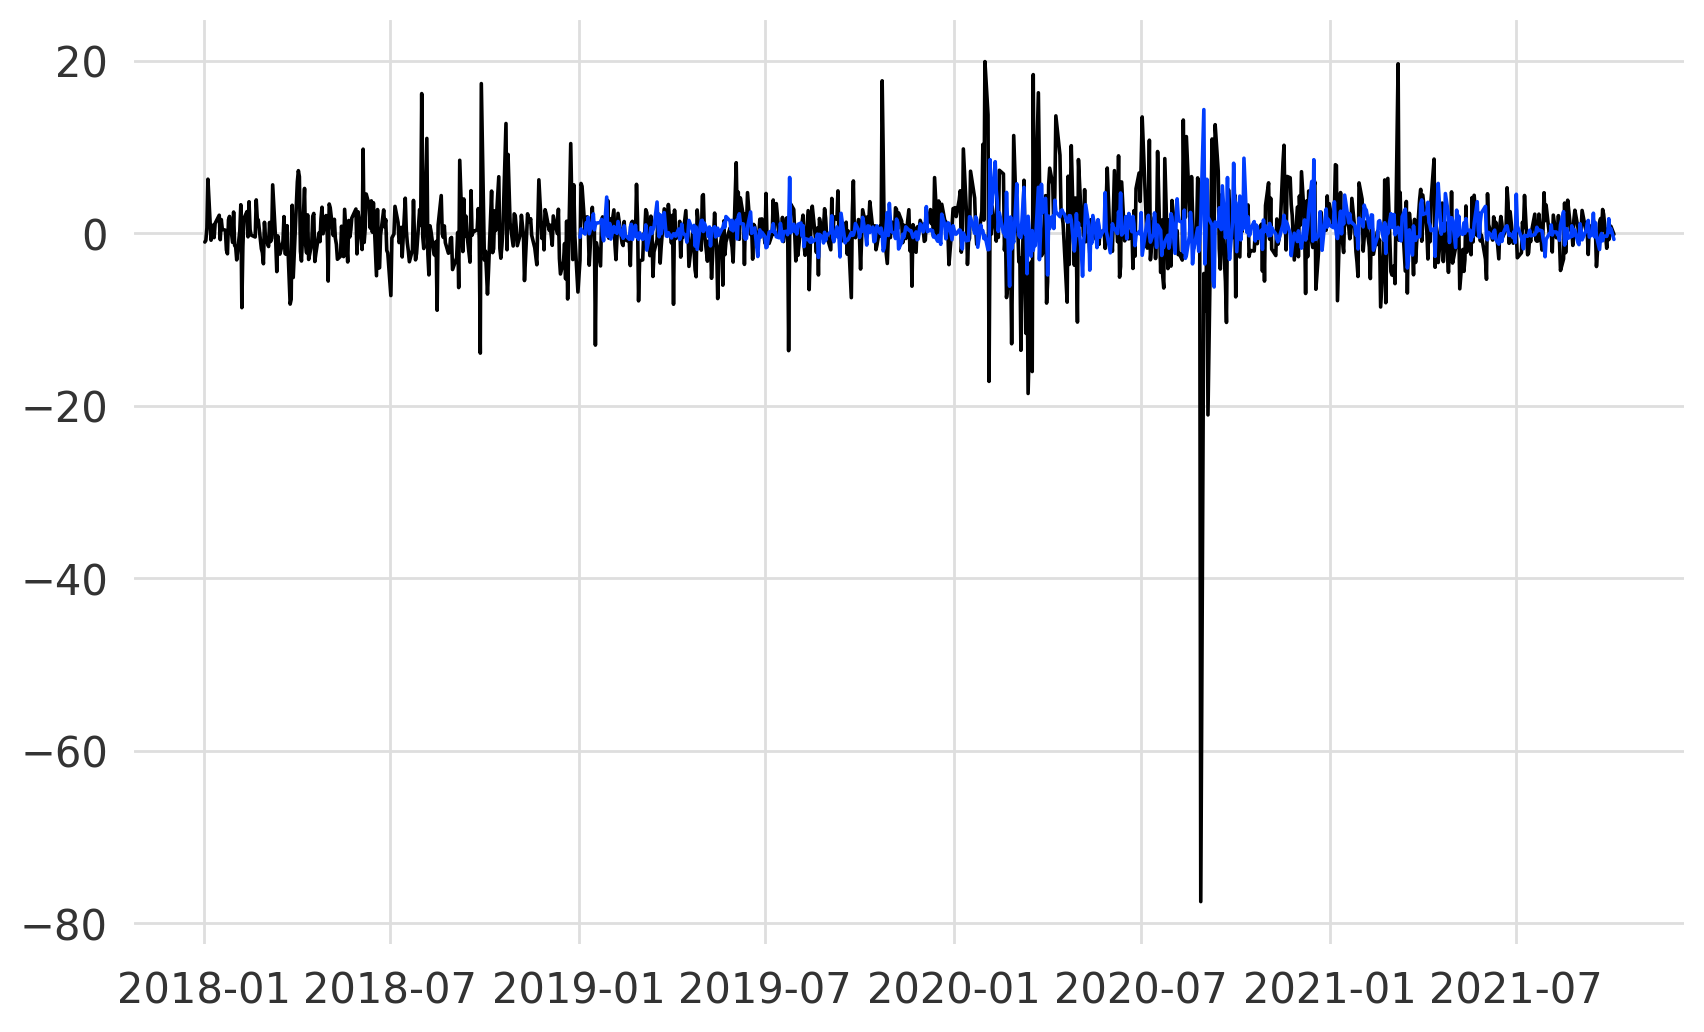

In [63]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(y["2018":], label="Ground Truth")
ax.plot(xgb_pred)

In [64]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

In [65]:
mean_squared_error(y_test, xgb_pred)

29.65884052965921

In [66]:
mean_squared_error(y_test, np.ones_like(y_test) * y_test.mean())

26.551338195389704

In [67]:
mean_squared_error(y_test, y_test.shift(1).fillna(0))

51.086028269445585